Pivot table

pivot table is summury function it's bering higher daimention of data

In [51]:
import pandas as pd
import numpy as np
import seaborn as sns

In [52]:
df=sns.load_dataset("tips")

In [53]:
df.head(5)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [54]:
df.groupby("sex")[["total_bill"]].mean()

/tmp/ipykernel_437/4156014264.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sex")[["total_bill"]].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [55]:
df.groupby(["sex","smoker"])[["total_bill"]].mean().unstack()

/tmp/ipykernel_437/2371648152.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["sex","smoker"])[["total_bill"]].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [56]:
#using pivot table
df.pivot_table(index="sex",columns="smoker",values="total_bill")

/tmp/ipykernel_437/85392905.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="sex",columns="smoker",values="total_bill")


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [57]:
df.pivot_table(index="sex",columns="smoker",values="total_bill",aggfunc="max")#aggfuns->sum,count,min,max,std,var..ect

/tmp/ipykernel_437/3310623077.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="sex",columns="smoker",values="total_bill",aggfunc="max")#aggfuns->sum,count,min,max,std,var..ect


smoker,Yes,No
sex,,
Male,50.81,48.33
Female,44.30,35.83


In [58]:
#all columns together but in new version of pandas we must specify the values
df.pivot_table(index="sex",columns="smoker",values=["total_bill","size","tip"],aggfunc="mean")["size"]

/tmp/ipykernel_437/1065004407.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="sex",columns="smoker",values=["total_bill","size","tip"],aggfunc="mean")["size"]


smoker,Yes,No
sex,,
Male,2.500000,2.711340
Female,2.242424,2.592593


In [59]:
#multidimentinal
df.pivot_table(index=["sex","smoker"],columns=["day","time"],aggfunc={'size':"max",'tip':"mean",'total_bill':"sum"})

/tmp/ipykernel_437/491908195.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=["sex","smoker"],columns=["day","time"],aggfunc={'size':"max",'tip':"mean",'total_bill':"sum"})


size                                         tip               \
day            Thur          Fri           Sat    Sun      Thur          Fri   
time          Lunch Dinner Lunch Dinner Dinner Dinner     Lunch Dinner Lunch   
sex    smoker                                                                  
Male   Yes      4.0    NaN   2.0    4.0    5.0    5.0  3.058000    NaN  1.90   
       No       6.0    NaN   NaN    2.0    4.0    6.0  2.941500    NaN   NaN   
Female Yes      4.0    NaN   2.0    2.0    4.0    3.0  2.990000    NaN  2.66   
       No       6.0    2.0   3.0    2.0    4.0    5.0  2.437083    3.0  3.00   

                                         total_bill                        \
day                        Sat       Sun       Thur           Fri           
time          Dinner    Dinner    Dinner      Lunch Dinner  Lunch  Dinner   
sex    smoker                                                               
Male   Yes     3.246  2.879259  3.521333     191.71   0.00  34.16  129.46   
       No      2.500  3.256563  3.115349     369.73   0.00   0.00   34.95   
Female Yes     2.700  2.868667  3.500000     134.53   0.00  39.78   48.80   
       No      3.250  2.724615  3.329286     381.58  18.78  15.98   22.75   

                                           
day             Sat           Sun          
time          Lunch  Dinner Lunch  Dinner  
sex    smoker                              
Male   Yes      0.0  589.62   0.0  392.12  
       No       0.0  637.73   0.0  877.34  
Female Yes      0.0  304.00   0.0   66.16  
       No       0.0  247.05   0.0  291.54

In [60]:
#margins=True -> gives the sum
df.pivot_table(index="sex",columns="smoker",values=["total_bill","size","tip"],aggfunc="sum",margins=True)

/tmp/ipykernel_437/1663678349.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index="sex",columns="smoker",values=["total_bill","size","tip"],aggfunc="sum",margins=True)


size                 tip                 total_bill                  
smoker    Yes     No  All     Yes      No     All        Yes       No      All
sex                                                                           
Male    150.0  263.0  413  183.07  302.00  485.07    1337.07  1919.75  3256.82
Female   74.0  140.0  214   96.74  149.77  246.51     593.27   977.68  1570.95
All     224.0  403.0  627  279.81  451.77  731.58    1930.34  2897.43  4827.77

In [61]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
df1=pd.read_csv("/content/drive/MyDrive/Pandas/expense_data.csv")

In [63]:
df1.head(5)

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [64]:
df1.columns

Index(['Date', 'Account', 'Category', 'Subcategory', 'Note', 'INR',
       'Income/Expense', 'Note.1', 'Amount', 'Currency', 'Account.1'],
      dtype='object')

In [65]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [66]:
df1.duplicated().sum()

np.int64(0)

In [67]:
df1.shape

(277, 11)

In [68]:
#date ->Dtype -> "object"-> we want datatime
df1["Date"]=pd.to_datetime(df1["Date"])

In [69]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [70]:
df1["month"]=df1["Date"].dt.month_name()

In [71]:
df1.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


<Axes: xlabel='month'>

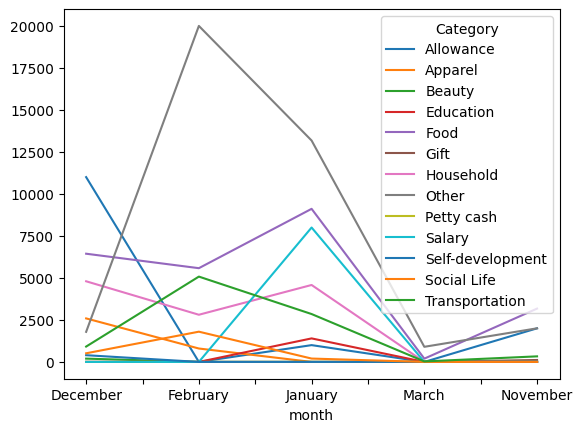

In [72]:
df1.pivot_table(index='month',columns="Category",values="INR",aggfunc="sum",fill_value=0).plot()

<Axes: xlabel='month'>

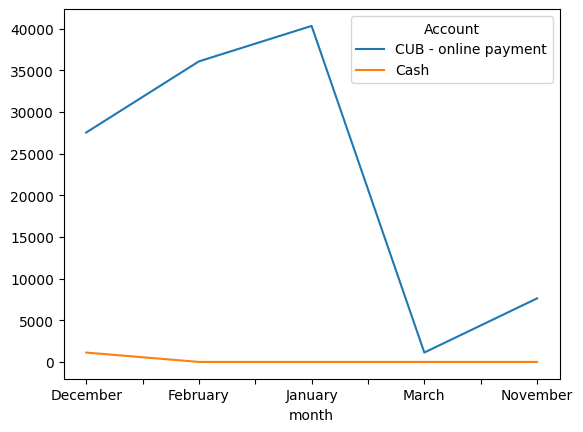

In [73]:
df1.pivot_table(index="month",columns="Account",values="INR",aggfunc="sum",fill_value=0).plot()

practice pivot table

In [74]:
np.random.seed(42)
departments = ['Sales', 'HR', 'IT', 'Finance', 'Marketing']
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', 'Pune']
genders = ['Male', 'Female']
employment = ['Full Time', 'Part Time']
data = {
    'Employee_ID': range(1001, 1101),
    'Department': np.random.choice(departments, 100),
    'City': np.random.choice(cities, 100),
    'Gender': np.random.choice(genders, 100),
    'Employment_Type': np.random.choice(employment, 100, p=[0.8,0.2]),
    'Experience_Years': np.random.randint(1, 15, 100),
    'Salary': np.random.randint(25000, 120000, 100),
    'Performance_Rating': np.random.randint(1, 6, 100),
    'Overtime_Hours': np.random.randint(0, 30, 100)
}
df = pd.DataFrame(data)
df.head()



,Employee_ID,Department,City,Gender,Employment_Type,Experience_Years,Salary,Performance_Rating,Overtime_Hours
0,1001,Finance,Hyderabad,Female,Full Time,10,63494,2,12
1,1002,Marketing,Mumbai,Female,Part Time,5,28373,4,13
2,1003,IT,Hyderabad,Female,Full Time,10,37161,1,2
3,1004,Marketing,Delhi,Male,Full Time,5,117658,5,28
4,1005,Marketing,Mumbai,Male,Full Time,14,52350,5,5


In [75]:
df.shape

(100, 9)

In [76]:
df["Employment_Type"].value_counts()

,count
Employment_Type,
Full Time,81
Part Time,19


In [77]:
df["Experience_Years"].max()

14

In [78]:
df.duplicated().sum()

np.int64(0)

queations are

In [79]:
#1) Find the average salary department-wise
df.pivot_table(index="Department",values="Salary",aggfunc="mean")

,Salary
Department,
Finance,71686.884615
HR,73275.142857
IT,81371.750000
Marketing,73472.842105
Sales,65146.388889


In [80]:
#Find the maximum experience in each department
df.pivot_table(index="Department",values="Experience_Years",aggfunc="max")

,Experience_Years
Department,
Finance,14
HR,14
IT,13
Marketing,14
Sales,14


In [81]:
#Find the average performance rating gender-wise.
df.pivot_table(index="Gender",values="Performance_Rating",aggfunc="mean")

,Performance_Rating
Gender,
Female,3.250000
Male,3.136364


In [82]:
#Find total overtime hours by employment type.
df.pivot_table(index="Employment_Type",values="Overtime_Hours",aggfunc="sum")

,Overtime_Hours
Employment_Type,
Full Time,1150
Part Time,244


In [83]:
df.pivot_table(index="Department",values="Employment_Type",aggfunc="count")

,Employment_Type
Department,
Finance,26
HR,21
IT,16
Marketing,19
Sales,18


In [84]:
df.head(5)

,Employee_ID,Department,City,Gender,Employment_Type,Experience_Years,Salary,Performance_Rating,Overtime_Hours
0,1001,Finance,Hyderabad,Female,Full Time,10,63494,2,12
1,1002,Marketing,Mumbai,Female,Part Time,5,28373,4,13
2,1003,IT,Hyderabad,Female,Full Time,10,37161,1,2
3,1004,Marketing,Delhi,Male,Full Time,5,117658,5,28
4,1005,Marketing,Mumbai,Male,Full Time,14,52350,5,5


In [85]:
df.pivot_table(index="Department",columns="Gender",values="Salary",aggfunc="mean")

Gender,Female,Male
Department,,
Finance,81812.583333,63007.714286
HR,70777.846154,77333.250000
IT,78391.625000,84351.875000
Marketing,68394.333333,82178.857143
Sales,76948.636364,46600.000000


In [86]:
df.pivot_table(index="Employment_Type",columns="City",values="Salary",aggfunc="mean")

City,Bangalore,Delhi,Hyderabad,Mumbai,Pune
Employment_Type,,,,,
Full Time,74093.222222,68293.083333,74351.157895,70859.409091,77480.700000
Part Time,73294.000000,58286.000000,78363.750000,62320.666667,76678.857143


In [87]:
df.pivot_table(index="Department",columns="City",values="Employment_Type",aggfunc="count")

City,Bangalore,Delhi,Hyderabad,Mumbai,Pune
Department,,,,,
Finance,NaN,3.0,6.0,12.0,5.0
HR,5.0,3.0,6.0,2.0,5.0
IT,8.0,2.0,5.0,NaN,1.0
Marketing,5.0,4.0,2.0,6.0,2.0
Sales,3.0,2.0,4.0,5.0,4.0


In [88]:
df.pivot_table(index="Department",columns="Gender",values="Salary",aggfunc="max")

Gender,Female,Male
Department,,
Finance,114112,108042
HR,118008,104459
IT,119297,117920
Marketing,96180,117658
Sales,114780,61208


In [89]:
df.pivot_table(index="Department",columns="Employment_Type",values="Salary",aggfunc="max")

Employment_Type,Full Time,Part Time
Department,,
Finance,113726,114112
HR,118008,45150
IT,119297,71959
Marketing,117658,114588
Sales,109076,114780


vectorized string operations

In [90]:
a=np.array([1,2,3,4])
a*4

array([ 4,  8, 12, 16])

In [91]:
#problem with vectorized operations in vanilla python
s=["cat","dog","None","mat"]
[i.startswith('c') for i in s]

[True, False, False, False]

In [92]:
s=pd.Series(["cat","mat","none","cat"])
s.str.startswith("c")

,0
0,True
1,False
2,False
3,True


In [93]:
df2=pd.read_csv("/content/drive/MyDrive/Pandas/titanic.csv")
df2.shape

(891, 12)

In [94]:
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [95]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [96]:
#common functions
#lower/upper/capitalize/title
#df["Name"].str.lower()
#df["Name"].str.upper()
#df["Name"].str.capitalize() #1st charecter of string shuold be capital
df2["Name"].str.title()

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [97]:
#strip (it will remove the extra space in the entire columns like "      vijay        ")
#"        vijay            ".strip()
df2["Name"].str.strip()

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [98]:
df2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [99]:
print(df2.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


Timestamp Object

Timestamps reference particular moments in time(eg:,june 27th,2026 at 7:00pm)


Creating Timestamp object

In [100]:
#creating timestamp
type(pd.Timestamp("2026/6/27"))

pandas._libs.tslibs.timestamps.Timestamp

In [101]:
#variations
pd.Timestamp("2026-6-27")
pd.Timestamp("2026, 6, 27")

Timestamp('2026-06-27 00:00:00')

In [102]:
#only year
pd.Timestamp("2026")

Timestamp('2026-01-01 00:00:00')

In [103]:
#using text
pd.Timestamp("27th june 2026")

Timestamp('2026-06-27 00:00:00')

In [104]:
#providing time
pd.Timestamp("27th june 2026 10:52am")

Timestamp('2026-06-27 10:52:00')

In [105]:
#using  datetime.datetime object
import datetime as dt
x=pd.Timestamp(dt.datetime(2026,6,27,10,57,21))
x

Timestamp('2026-06-27 10:57:21')

In [106]:
#featching attribues
print(x.year)
print(x.month)
print(x.day)
print(x.min)

2026
6
27
-290308-12-21 19:59:05.224193


DatetimeIndex Object

A collection of pandas timestamp

In [107]:
#from string
type(pd.DatetimeIndex(['2023/1/1','2022/1/1','2021/1/1']))

pandas.core.indexes.datetimes.DatetimeIndex

In [108]:
#using pyhton datetime object
pd.DatetimeIndex([dt.datetime(2023,1,1),dt.datetime(2022,1,1),dt.datetime(2021,1,1)])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [109]:
#using pd.timestamp
dt_index=pd.DatetimeIndex([pd.Timestamp(2023,1,1),pd.Timestamp(2022,1,1),pd.Timestamp(2021,1,1)])

In [110]:
#using datetimeindex as series index
pd.Series([1,2,3],index=dt_index)

,0
2023-01-01,1
2022-01-01,2
2021-01-01,3


date_range fuction

In [111]:
#print alternate days in a given range
pd.date_range(start='2026/6/28',end='2026/7/28',freq="2D")

DatetimeIndex(['2026-06-28', '2026-06-30', '2026-07-02', '2026-07-04',
               '2026-07-06', '2026-07-08', '2026-07-10', '2026-07-12',
               '2026-07-14', '2026-07-16', '2026-07-18', '2026-07-20',
               '2026-07-22', '2026-07-24', '2026-07-26', '2026-07-28'],
              dtype='datetime64[ns]', freq='2D')

In [112]:
#B -> business days
pd.date_range(start='2026/6/28',end='2026/7/28',freq="B")

DatetimeIndex(['2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02',
               '2026-07-03', '2026-07-06', '2026-07-07', '2026-07-08',
               '2026-07-09', '2026-07-10', '2026-07-13', '2026-07-14',
               '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-20',
               '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24',
               '2026-07-27', '2026-07-28'],
              dtype='datetime64[ns]', freq='B')

In [113]:
#W ->ONE DAY PER WEEK
pd.date_range(start='2026/6/28',end='2026/7/28',freq="W")

DatetimeIndex(['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19',
               '2026-07-26'],
              dtype='datetime64[ns]', freq='W-SUN')

In [114]:
#one day per week according to the preference
pd.date_range(start='2026/6/28',end='2026/7/28',freq="W-wed")

DatetimeIndex(['2026-07-01', '2026-07-08', '2026-07-15', '2026-07-22'], dtype='datetime64[ns]', freq='W-WED')

In [115]:
#H->Hourly date(factor)
pd.date_range(start='2026/6/28',end='2026/7/28',freq="6H")

/tmp/ipykernel_437/1087362609.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start='2026/6/28',end='2026/7/28',freq="6H")


DatetimeIndex(['2026-06-28 00:00:00', '2026-06-28 06:00:00',
               '2026-06-28 12:00:00', '2026-06-28 18:00:00',
               '2026-06-29 00:00:00', '2026-06-29 06:00:00',
               '2026-06-29 12:00:00', '2026-06-29 18:00:00',
               '2026-06-30 00:00:00', '2026-06-30 06:00:00',
               ...
               '2026-07-25 18:00:00', '2026-07-26 00:00:00',
               '2026-07-26 06:00:00', '2026-07-26 12:00:00',
               '2026-07-26 18:00:00', '2026-07-27 00:00:00',
               '2026-07-27 06:00:00', '2026-07-27 12:00:00',
               '2026-07-27 18:00:00', '2026-07-28 00:00:00'],
              dtype='datetime64[ns]', length=121, freq='6h')

In [116]:
# M->Month end
pd.date_range(start='2026/6/28',end='2026/7/28',freq="M")


/tmp/ipykernel_437/4081686068.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(start='2026/6/28',end='2026/7/28',freq="M")


DatetimeIndex(['2026-06-30'], dtype='datetime64[ns]', freq='ME')

TO_DATETIME FUNCTION

convert an existing to pandas timestamp/detetimeindex object

In [117]:
#simple  series example
s=pd.Series(['2026/6/28','2027/7/28','2028/08/28'])
pd.to_datetime(s).dt.day_name()

,0
0,Sunday
1,Wednesday
2,Monday


In [118]:
#with error
s=pd.Series(['2026/6/28','2027/7/28','2028/130/28'])
pd.to_datetime(s,errors='coerce').dt.year #we can feach the year with any problem


,0
0,2026.0
1,2027.0
2,NaN


In [119]:
df1.head(5)

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


In [120]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
 11  month           277 non-null    object        
dtypes: datetime64[ns](1), float64(5), object(6)
memory usage: 26.1+ KB


In [121]:
df1

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March
...,...,...,...,...,...,...,...,...,...,...,...,...
272,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0,November
273,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0,November
274,2021-11-21 17:07:00,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0,November
275,2021-11-21 15:50:00,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0,November


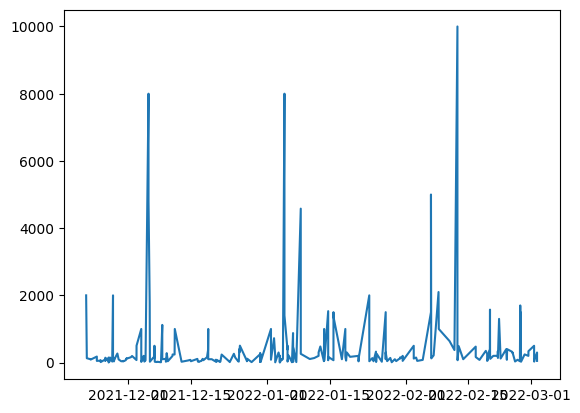

In [124]:
import matplotlib.pyplot as plt
plt.plot(df1["Date"],df1["INR"])
plt.show()


In [126]:
#day name wise bar chart/month wise bar chart
df1["day_name"]=df1["Date"].dt.day_name()


In [127]:
df1.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month,day_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March,Tuesday


<Axes: xlabel='day_name'>

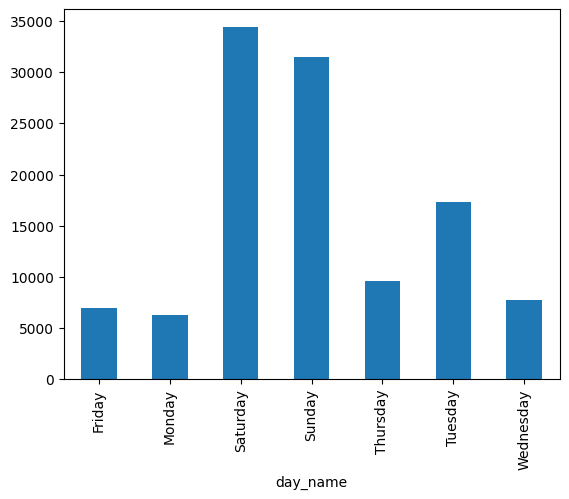

In [129]:
df1.groupby("day_name")["INR"].sum().plot(kind="bar")

In [130]:
df1["month_name"]=df1["Date"].dt.month_name()

<Axes: xlabel='month_name'>

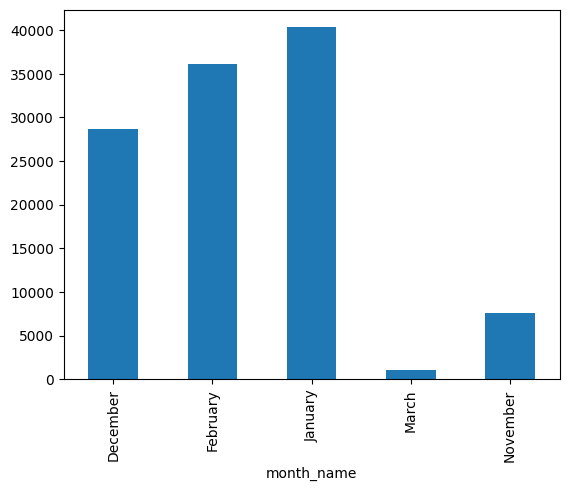

In [131]:
df1.groupby("month_name")["INR"].sum().plot(kind="bar")

In [137]:
df1[df1["Date"].dt.is_month_end]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month,day_name,month_name
7,2022-02-28 11:56:00,CUB - online payment,Food,NaN,Pizza,339.15,Expense,NaN,339.15,INR,339.15,February,Monday,February
8,2022-02-28 11:45:00,CUB - online payment,Other,NaN,From kumara,200.00,Income,NaN,200.00,INR,200.00,February,Monday,February
61,2022-01-31 08:44:00,CUB - online payment,Transportation,NaN,Vnr to apk,50.00,Expense,NaN,50.00,INR,50.00,January,Monday,January
62,2022-01-31 08:27:00,CUB - online payment,Other,NaN,To vicky,200.00,Expense,NaN,200.00,INR,200.00,January,Monday,January
63,2022-01-31 08:26:00,CUB - online payment,Transportation,NaN,To ksr station,153.00,Expense,NaN,153.00,INR,153.00,January,Monday,January
242,2021-11-30 14:24:00,CUB - online payment,Gift,NaN,Bharath birthday,115.00,Expense,NaN,115.00,INR,115.00,November,Tuesday,November
243,2021-11-30 14:17:00,CUB - online payment,Food,NaN,Lunch with company,128.00,Expense,NaN,128.00,INR,128.00,November,Tuesday,November
244,2021-11-30 10:11:00,CUB - online payment,Food,NaN,Breakfast,70.00,Expense,NaN,70.00,INR,70.00,November,Tuesday,November
